# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aleezafatima-21/Aleeza-flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
import os
import duckdb
import numpy as np
import pandas as pd
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")
con.execute(
    "CREATE OR REPLACE SECRET hf_secret (TYPE HUGGINGFACE, TOKEN ?)",
    [os.environ["HF_TOKEN"]]
)

feature_frame = con.execute("""
    SELECT
        content_hash_id,
        ANY_VALUE(client_hash_id) AS client_hash_id,
        SUM(gsc_impressions) AS gsc_impressions,
        SUM(gsc_clicks) AS gsc_clicks,
        AVG(gsc_avg_position) AS gsc_avg_position,
        SUM(ga4_sessions) AS ga4_sessions,
        SUM(ga4_engaged_sessions) AS ga4_engaged_sessions
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')
    GROUP BY content_hash_id
""").df()

label_data = con.execute("""
    WITH march AS (
        SELECT content_hash_id, SUM(gsc_impressions) AS march_impressions
        FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')
        GROUP BY content_hash_id
    ),
    april AS (
        SELECT content_hash_id, SUM(gsc_impressions) AS april_impressions
        FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/*.parquet')
        GROUP BY content_hash_id
    )
    SELECT march.content_hash_id, march.march_impressions, april.april_impressions,
        CASE WHEN april.april_impressions < march.march_impressions THEN 1 ELSE 0 END AS is_declining_label
    FROM march INNER JOIN april ON march.content_hash_id = april.content_hash_id
""").df()

data = feature_frame.merge(label_data[["content_hash_id", "is_declining_label"]], on="content_hash_id", how="inner")
data = data.sort_values("content_hash_id").reset_index(drop=True)
print("Rows:", len(data))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 331436


In [3]:
features = ["gsc_impressions", "gsc_clicks", "gsc_avg_position", "ga4_sessions", "ga4_engaged_sessions"]

from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data["client_hash_id"]))
train = data.iloc[train_idx].copy()
test = data.iloc[test_idx].copy()

train_medians = train[features].copy()
train_medians["gsc_avg_position"] = train_medians["gsc_avg_position"].replace(0, np.nan)
train_medians = train_medians.median()

def prep(d):
    X = d[features].copy()
    X["gsc_avg_position"] = X["gsc_avg_position"].replace(0, np.nan)
    return X.fillna(train_medians)

X_train, X_test = prep(train), prep(test)
y_train, y_test = train["is_declining_label"], test["is_declining_label"]

imp_median = train["gsc_impressions"].median()
print("Train:", len(train), "Test:", len(test))

Train: 300879 Test: 30557


In [4]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Trained.")

Trained.


In [5]:
# ML-10: Rebuild ranked_test

rf_proba = rf_model.predict_proba(X_test)[:, 1]

ranked_test = test.copy()
ranked_test["rf_score"] = rf_proba
ranked_test["actual_decline"] = y_test.values

ranked_test = ranked_test.sort_values("rf_score", ascending=False).reset_index(drop=True)

print("Ranked test rows:", len(ranked_test))
print(ranked_test[["content_hash_id", "rf_score", "actual_decline"]].head())

Ranked test rows: 30557
            content_hash_id  rf_score  actual_decline
0  content_9d9713f2a48067c8  0.864698               1
1  content_c0407691d2c3c153  0.844228               0
2  content_2b74174acd8039c7  0.827519               0
3  content_f9e04ee043a37ad6  0.818955               1
4  content_ecc27d32010b18e0  0.816421               1


In [6]:
# ML-10: Build ranked action queue with reason codes

top_n = ranked_test.head(100).copy()

def reason_code(row):
    if row["rf_score"] >= 0.7 and row["gsc_impressions"] >= imp_median:
        return "High-priority review — high traffic, high decline risk"
    elif row["rf_score"] >= 0.7:
        return "Review — declining risk flagged, lower current traffic"
    else:
        return "Monitor — moderate risk"

top_n["reason_code"] = top_n.apply(reason_code, axis=1)

print(top_n[["content_hash_id", "rf_score", "reason_code"]].head(10))
print("\nReason code counts:")
print(top_n["reason_code"].value_counts())

            content_hash_id  rf_score  \
0  content_9d9713f2a48067c8  0.864698   
1  content_c0407691d2c3c153  0.844228   
2  content_2b74174acd8039c7  0.827519   
3  content_f9e04ee043a37ad6  0.818955   
4  content_ecc27d32010b18e0  0.816421   
5  content_bc70bdc12eb6657c  0.813913   
6  content_b303e10b0a71885f  0.811225   
7  content_6eba4aad3540c6a4  0.807907   
8  content_f6e9d625e6f612b5  0.807206   
9  content_7d71db9cad5304cf  0.804934   

                                         reason_code  
0  High-priority review — high traffic, high decl...  
1  High-priority review — high traffic, high decl...  
2  High-priority review — high traffic, high decl...  
3  High-priority review — high traffic, high decl...  
4  High-priority review — high traffic, high decl...  
5  High-priority review — high traffic, high decl...  
6  High-priority review — high traffic, high decl...  
7  High-priority review — high traffic, high decl...  
8  High-priority review — high traffic, high decl... 

In [7]:
# ML-10: Improved reason codes — thresholds based on the top-N population itself

impressions_75th = top_n["gsc_impressions"].quantile(0.75)
impressions_25th = top_n["gsc_impressions"].quantile(0.25)

def reason_code(row):
    if row["gsc_impressions"] >= impressions_75th:
        return "High-priority review — high traffic, high decline risk"
    elif row["gsc_impressions"] <= impressions_25th:
        return "Low-traffic flag — declining risk, limited current reach"
    else:
        return "Standard review — moderate traffic, declining risk"

top_n["reason_code"] = top_n.apply(reason_code, axis=1)

print(top_n[["content_hash_id", "rf_score", "gsc_impressions", "reason_code"]].head(10))
print("\nReason code counts:")
print(top_n["reason_code"].value_counts())

            content_hash_id  rf_score  gsc_impressions  \
0  content_9d9713f2a48067c8  0.864698            771.0   
1  content_c0407691d2c3c153  0.844228           2482.0   
2  content_2b74174acd8039c7  0.827519            832.0   
3  content_f9e04ee043a37ad6  0.818955           2962.0   
4  content_ecc27d32010b18e0  0.816421           3900.0   
5  content_bc70bdc12eb6657c  0.813913           2874.0   
6  content_b303e10b0a71885f  0.811225            213.0   
7  content_6eba4aad3540c6a4  0.807907           3901.0   
8  content_f6e9d625e6f612b5  0.807206           4048.0   
9  content_7d71db9cad5304cf  0.804934           1919.0   

                                         reason_code  
0  Low-traffic flag — declining risk, limited cur...  
1  High-priority review — high traffic, high decl...  
2  Low-traffic flag — declining risk, limited cur...  
3  High-priority review — high traffic, high decl...  
4  High-priority review — high traffic, high decl...  
5  High-priority review — high 

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [8]:
# ML-10: Export ranked action queue for the paper

import os
os.makedirs("work/outputs", exist_ok=True)
top_n.to_csv("work/outputs/ranked_action_queue.csv", index=False)
print("Saved:", len(top_n), "rows to work/outputs/ranked_action_queue.csv")

Saved: 100 rows to work/outputs/ranked_action_queue.csv


In [9]:
import os

print("Folders inside /content:\n")

for item in os.listdir("/content"):
    print(item)

Folders inside /content:

.config
work
sample_data


In [10]:
import os

for root, dirs, files in os.walk("/content/work"):
    level = root.replace("/content/work", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}  {file}")


work/
  outputs/
    ranked_action_queue.csv


In [13]:
# Show Random Forest-related variables safely
for name, value in list(globals().items()):
    if "rf" in name.lower() or "random" in name.lower() or "forest" in name.lower():
        print(name, type(value))

RandomForestClassifier <class 'abc.ABCMeta'>
rf_model <class 'sklearn.ensemble._forest.RandomForestClassifier'>
rf_proba <class 'numpy.ndarray'>


In [14]:
# Get the exact feature importances from the trained Random Forest
import pandas as pd

print("Feature importance values:")

for feature, importance in zip(
    X_train.columns,
    rf_model.feature_importances_
):
    print(f"{feature}: {importance:.6f}")

Feature importance values:
gsc_impressions: 0.660708
gsc_clicks: 0.067865
gsc_avg_position: 0.242331
ga4_sessions: 0.028073
ga4_engaged_sessions: 0.001023


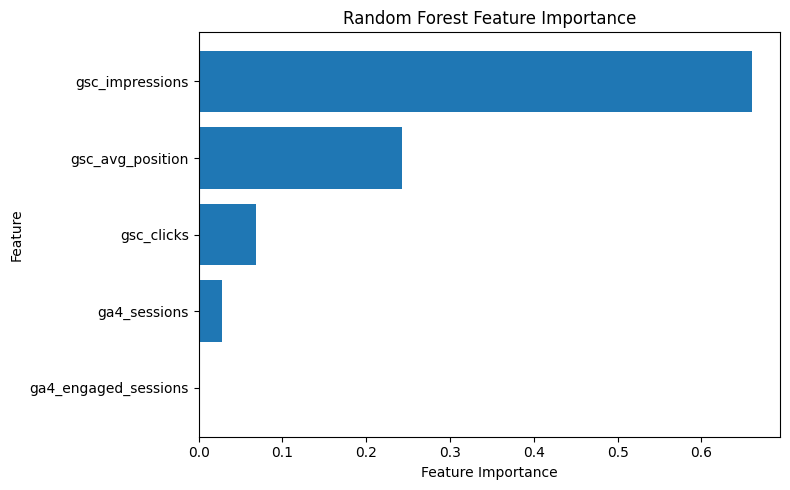

Final figure saved: /content/work/figures/feature_importance.png


In [15]:
import os
import matplotlib.pyplot as plt

# Exact feature importances from the final Random Forest model
features = [
    "gsc_impressions",
    "gsc_avg_position",
    "gsc_clicks",
    "ga4_sessions",
    "ga4_engaged_sessions"
]

importances = [
    0.660708,
    0.242331,
    0.067865,
    0.028073,
    0.001023
]

# Make sure the output directory exists
os.makedirs("/content/work/figures", exist_ok=True)

# Create the figure
plt.figure(figsize=(8, 5))
plt.barh(features[::-1], importances[::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

# Save the final figure
output_path = "/content/work/figures/feature_importance.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Final figure saved:", output_path)

In [17]:
# Show important metric variables currently available
for name, value in list(globals().items()):
    if any(word in name.lower() for word in ["metric", "auc", "precision", "recall", "f1"]):
        if not callable(value):
            print(name, "=", value)

In [18]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# Use the existing test predictions
rf_pred = (rf_proba >= 0.5).astype(int)

print("Random Forest final metrics")
print("--------------------------------")
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print("Average Precision:", average_precision_score(y_test, rf_proba))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Random Forest final metrics
--------------------------------
ROC-AUC: 0.8512857620109358
Average Precision: 0.6536479924931924
Precision: 0.6015715416945849
Recall: 0.9779186058025547
F1: 0.7449087343490722


In [19]:
import json
import os

metrics = {
    "model": "random_forest",
    "roc_auc": 0.8512857620109358,
    "average_precision": 0.6536479924931924,
    "precision": 0.6015715416945849,
    "recall": 0.9779186058025547,
    "f1": 0.7449087343490722,
    "precision_at_50": 0.78
}

# Make sure the output directory exists
os.makedirs("/content/work/outputs", exist_ok=True)

# Save metrics
output_path = "/content/work/outputs/w05_model_metrics.json"

with open(output_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics JSON saved:", output_path)

# Display the contents so we can verify them
print("\nContents:")
with open(output_path, "r") as f:
    print(f.read())

Metrics JSON saved: /content/work/outputs/w05_model_metrics.json

Contents:
{
  "model": "random_forest",
  "roc_auc": 0.8512857620109358,
  "average_precision": 0.6536479924931924,
  "precision": 0.6015715416945849,
  "recall": 0.9779186058025547,
  "f1": 0.7449087343490722,
  "precision_at_50": 0.78
}


In [20]:
import os

files = [
    "/content/work/outputs/w05_model_metrics.json",
    "/content/work/figures/feature_importance.png",
    "/content/work/outputs/ranked_action_queue.csv"
]

for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file)
        print(f"✅ {file} — {size:,} bytes")
    else:
        print(f"❌ {file} — NOT FOUND")

✅ /content/work/outputs/w05_model_metrics.json — 228 bytes
✅ /content/work/figures/feature_importance.png — 95,410 bytes
✅ /content/work/outputs/ranked_action_queue.csv — 16,826 bytes


In [25]:
!git clone https://github.com/aleezafatima-21/Aleeza-flyrank-ml-internship.git /content/Aleeza-flyrank-ml-internship

Cloning into '/content/Aleeza-flyrank-ml-internship'...
remote: Enumerating objects: 336, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 336 (delta 62), reused 15 (delta 15), pack-reused 227 (from 1)
Receiving objects: 100% (336/336), 1.99 MiB | 8.69 MiB/s, done.
Resolving deltas: 100% (183/183), done.


In [26]:
!git -C /content/work ls-files | grep ranked_action_queue

fatal: not a git repository (or any of the parent directories): .git


In [27]:
!find /content -maxdepth 3 -type d -name ".git" -print

/content/Aleeza-flyrank-ml-internship/.git


In [28]:
import shutil
import os

repo = "/content/Aleeza-flyrank-ml-internship"

# Create required directories
os.makedirs(f"{repo}/work/outputs", exist_ok=True)
os.makedirs(f"{repo}/work/figures", exist_ok=True)

# Copy the metrics JSON
shutil.copy(
    "/content/work/outputs/w05_model_metrics.json",
    f"{repo}/work/outputs/w05_model_metrics.json"
)

# Copy the feature importance figure
shutil.copy(
    "/content/work/figures/feature_importance.png",
    f"{repo}/work/figures/feature_importance.png"
)

print("✅ Metrics JSON copied")
print("✅ Feature importance figure copied")
print("\nFiles now in repository:")

for path in [
    f"{repo}/work/outputs/w05_model_metrics.json",
    f"{repo}/work/figures/feature_importance.png"
]:
    print("✅", path)

✅ Metrics JSON copied
✅ Feature importance figure copied

Files now in repository:
✅ /content/Aleeza-flyrank-ml-internship/work/outputs/w05_model_metrics.json
✅ /content/Aleeza-flyrank-ml-internship/work/figures/feature_importance.png


In [29]:
!git -C /content/Aleeza-flyrank-ml-internship status --short

?? work/figures/
?? work/outputs/


In [30]:
!git -C /content/Aleeza-flyrank-ml-internship status --short --untracked-files=all

?? work/figures/feature_importance.png
?? work/outputs/w05_model_metrics.json


In [31]:
import os

gitignore = "/content/Aleeza-flyrank-ml-internship/.gitignore"

if os.path.exists(gitignore):
    print("Current .gitignore:\n")
    with open(gitignore, "r") as f:
        print(f.read())
else:
    print("❌ .gitignore does not exist")

Current .gitignore:

# --- Data leak guard -------------------------------------------------------
# Block every dataset by default. Only the tiny anonymized starter slice ships.
data/**
!data/
!data/raw/
!data/raw/content_refresh_anonymized.csv

# Never commit bulk dataset dumps or archives
*.parquet
*.zip
*.tar
*.tar.gz
*.feather

# --- Generated pipeline artifacts -----------------------------------------
# data/processed is regenerated by the pipeline
data/processed/
# outputs: keep the small committed examples (model_report.md, charts/,
# refresh_queue_sample.csv), ignore regenerated heavy artifacts
outputs/*.pdf
outputs/model_results.json
outputs/summary.json
outputs/*.csv
!outputs/refresh_queue_sample.csv

# --- Intern work area ------------------------------------------------------
# your experiments live in work/; datasets never enter git
work/**/*.csv

# --- Python / notebooks ----------------------------------------------------
__pycache__/
*.py[cod]
.ipynb_checkpoints/
.ven

In [32]:
!git -C /content/Aleeza-flyrank-ml-internship add \
    work/figures/feature_importance.png \
    work/outputs/w05_model_metrics.json

print("✅ Two files staged.")

✅ Two files staged.


In [33]:
!git -C /content/Aleeza-flyrank-ml-internship status --short

A  work/figures/feature_importance.png
A  work/outputs/w05_model_metrics.json


In [37]:
!git -C /content/Aleeza-flyrank-ml-internship commit -m "Add metrics JSON and feature importance figure"

[main 6ecee2b] Add metrics JSON and feature importance figure
 2 files changed, 9 insertions(+)
 create mode 100644 work/figures/feature_importance.png
 create mode 100644 work/outputs/w05_model_metrics.json


In [36]:
!git -C /content/Aleeza-flyrank-ml-internship config user.name "aleezafatima-21"
!git -C /content/Aleeza-flyrank-ml-internship config user.email "aleezaf408@gmail.com"

print("✅ Git identity configured.")

✅ Git identity configured.


In [38]:
!git -C /content/Aleeza-flyrank-ml-internship push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [39]:
!git -C /content/Aleeza-flyrank-ml-internship remote -v

origin	https://github.com/aleezafatima-21/Aleeza-flyrank-ml-internship.git (fetch)
origin	https://github.com/aleezafatima-21/Aleeza-flyrank-ml-internship.git (push)


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.